In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
path='/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled'
print(len(os.listdir(path)))

69


In [4]:
!pip install nibabel

In [5]:
import os

img_paths = []

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith("_img.nii.gz"):
            img_paths.append(os.path.join(root, f))

print("Total scans:", len(img_paths))
print(img_paths[:3])

Total scans: 69
['/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/6c155d7b3ad5/6c155d7b3ad5_img.nii.gz', '/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/61aa61a02290/61aa61a02290_img.nii.gz', '/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/d460b3282183/d460b3282183_img.nii.gz']


In [6]:
import os
import cv2
import numpy as np
import nibabel as nib
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import nibabel as nib

HEART SEGMENTATION BASELINE MODEL TRAINING. GROUND TRUTH'S BEING DERIVED FROM TOTALSEGMENTATOR

In [7]:
!pip install nnunetv2

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [1]:
!pip install TotalSegmentator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 7.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
import os
import subprocess
import nibabel as nib
import numpy as np
import shutil
import torch
import time
from scipy.ndimage import binary_closing, binary_fill_holes

print(torch.cuda.get_device_name(0))

DATA_ROOT = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled"
TEMP_DIR = "/content/temp_seg"

os.makedirs(TEMP_DIR, exist_ok=True)

heart_parts = [
    "heart_myocardium.nii.gz",
    "heart_atrium_left.nii.gz",
    "heart_atrium_right.nii.gz",
    "heart_ventricle_left.nii.gz",
    "heart_ventricle_right.nii.gz"
]

ts_times = []  # store inference times

for patient_id in os.listdir(DATA_ROOT):

    patient_dir = os.path.join(DATA_ROOT, patient_id)

    if not os.path.isdir(patient_dir):
        continue

    print(f"\nProcessing patient: {patient_id}")

    img_file = None
    for f in os.listdir(patient_dir):
        if f.endswith("_img.nii.gz"):
            img_file = f
            break

    if img_file is None:
        print("No image found.")
        continue

    img_path = os.path.join(patient_dir, img_file)

    case_name = img_file.replace("_img.nii.gz","")

    heartmask_path = os.path.join(patient_dir, case_name + "_heartmask.nii.gz")

    if os.path.exists(heartmask_path):
        print("Heart mask already exists, skipping.")
        continue

    case_temp = os.path.join(TEMP_DIR, case_name)

    # START TIMER
    start_time = time.time()

    subprocess.run([
        "TotalSegmentator",
        "-i", img_path,
        "-o", case_temp,
        "-ta", "heartchambers_highres",
        "-l", "aca_252I6K3VSV3BB9",
        "-d", "gpu"
    ])

    # END TIMER
    end_time = time.time()

    elapsed = end_time - start_time
    ts_times.append(elapsed)

    print(f"TotalSegmentator inference time: {elapsed:.2f} sec")

    mask = None
    affine = None

    for part in heart_parts:

        part_path = os.path.join(case_temp, part)

        if not os.path.exists(part_path):
            continue

        nii = nib.load(part_path)
        data = nii.get_fdata()

        if mask is None:
            mask = data
            affine = nii.affine
        else:
            mask += data

    if mask is None:
        print("Heart structures not found.")
        continue

    # Convert to binary
    mask = mask > 0

    # Morphological cleanup
    mask = binary_closing(mask, iterations=2)
    mask = binary_fill_holes(mask)

    mask = mask.astype(np.uint8)

    nib.save(
        nib.Nifti1Image(mask, affine),
        heartmask_path
    )

    shutil.rmtree(case_temp)

    print(f"Saved heart mask → {heartmask_path}")

# FINAL AVERAGE TIME
if len(ts_times) > 0:
    avg_ts_time = sum(ts_times) / len(ts_times)
    print(f"\nAverage TotalSegmentator Time per scan: {avg_ts_time:.2f} sec")
else:
    print("\nNo scans processed for timing.")

Tesla T4

Processing patient: 6c155d7b3ad5
Heart mask already exists, skipping.

Processing patient: 61aa61a02290
Heart mask already exists, skipping.

Processing patient: d460b3282183
Heart mask already exists, skipping.

Processing patient: 6526e1ec0885
Heart mask already exists, skipping.

Processing patient: 2d09edb4c90e
Heart mask already exists, skipping.

Processing patient: 728a7e45289d
Heart mask already exists, skipping.

Processing patient: a0a4f18a588a
Heart mask already exists, skipping.

Processing patient: c7bc4129f3ae
Heart mask already exists, skipping.

Processing patient: eda70fd9244e
Heart mask already exists, skipping.

Processing patient: de1c018ed087
Heart mask already exists, skipping.

Processing patient: 56180036837b
Heart mask already exists, skipping.

Processing patient: 60ec74a7bb2b
Heart mask already exists, skipping.

Processing patient: 4547b651089d
Heart mask already exists, skipping.

Processing patient: e96c18a1066b
Heart mask already exists, skippin

OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/8ae11c559e91/8ae11c559e91_heartmask.nii.gz'

In [9]:
heartmask_ids = [
"6c155d7b3ad5",
"61aa61a02290",
"d460b3282183",
"6526e1ec0885",
"2d09edb4c90e",
"728a7e45289d",
"a0a4f18a588a",
"c7bc4129f3ae",
"eda70fd9244e",
"de1c018ed087",
"56180036837b",
"60ec74a7bb2b",
"4547b651089d",
"e96c18a1066b",
"e86d325dcd83",
"42aa11505a4d",
"f803b1fc82f9",
"7b4e1d4ec091",
"0bc4b3e38ecb",
"e4033755ea6d",
"671350fd47fa",
"9abedacc08fa",
"cd0125fa3931",
"4aedc3773c08",
"2698cf0c9f2d",
"8bcbd115d859",
"21c0c1992392",
"b6b5a669a1f9",
"5b3690080756",
"5fb7611792aa",
"f1118c75d54d",
"0174d50143cd",
"36d3543914f9",
"39eefcd32189",
"3722621f0a8d"
]

In [10]:
import json

save_path = "/content/drive/MyDrive/PREDICT-COCA_seg/heartmask_ids.json"

with open(save_path, "w") as f:
    json.dump(heartmask_ids, f)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/PREDICT-COCA_seg/heartmask_ids.json


In [11]:
import json

with open("/content/drive/MyDrive/PREDICT-COCA_seg/heartmask_ids.json") as f:
    heartmask_ids = json.load(f)

In [12]:
import nibabel as nib
import os

root = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled"

pid = heartmask_ids[0]

img = nib.load(os.path.join(root, pid, pid + "_img.nii.gz")).get_fdata()

print(img.shape)

(243, 243, 171)


In [ ]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(
    heartmask_ids,
    test_size=0.2,
    random_state=42
)

print("Train patients:", len(train_ids))
print("Val patients:", len(val_ids))

Train patients: 28
Val patients: 7


In [ ]:
WINDOW_MIN = -150
WINDOW_MAX = 250
import cv2
import nibabel as nib
import numpy as np
import os

TARGET = 192
NEG_RATIO = 0.05

WINDOW_MIN = -150
WINDOW_MAX = 250

DATA_ROOT = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled"


def extract_slices(patient_ids):

    images = []
    masks = []

    for pid in patient_ids:

        patient_dir = os.path.join(DATA_ROOT, pid)

        img_path = os.path.join(patient_dir, pid + "_img.nii.gz")
        mask_path = os.path.join(patient_dir, pid + "_heartmask.nii.gz")

        img = nib.load(img_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()

        pos_slices = []
        neg_slices = []

        for z in range(img.shape[2]):

            if np.sum(mask[:,:,z]) > 0:
                pos_slices.append(z)
            else:
                neg_slices.append(z)

        # sample negatives
        n_neg = int(len(neg_slices) * NEG_RATIO)

        if n_neg > 0:
            neg_sample = np.random.choice(neg_slices, n_neg, replace=False)
        else:
            neg_sample = []

        selected = list(pos_slices) + list(neg_sample)

        for z in selected:

            im = img[:,:,z]
            ma = mask[:,:,z]

            # heart window
            im = np.clip(im, WINDOW_MIN, WINDOW_MAX)
            im = (im - WINDOW_MIN) / (WINDOW_MAX - WINDOW_MIN)

            im = cv2.resize(im,(TARGET,TARGET))
            ma = cv2.resize(ma,(TARGET,TARGET), interpolation=cv2.INTER_NEAREST)

            images.append(im.astype(np.float32))
            masks.append(ma.astype(np.float32))

    return np.array(images), np.array(masks)

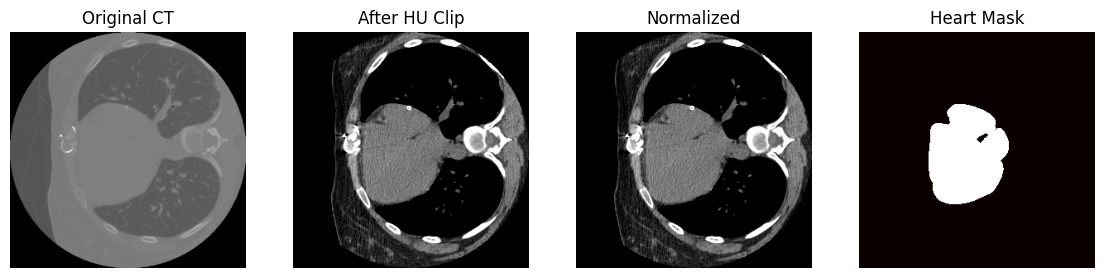

Slice: 90
Original HU range: -3024.0 3071.0
Clipped HU range: -150.0 250.0


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
import random

DATA_ROOT = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled"

WINDOW_MIN = -150
WINDOW_MAX = 250

# pick random patient
pid = random.choice(train_ids)

patient_dir = os.path.join(DATA_ROOT, pid)

img = nib.load(os.path.join(patient_dir, pid + "_img.nii.gz")).get_fdata()
mask = nib.load(os.path.join(patient_dir, pid + "_heartmask.nii.gz")).get_fdata()

# pick slice containing heart
valid_slices = np.where(mask.sum(axis=(0,1)) > 0)[0]
z = random.choice(valid_slices)

slice_img = img[:,:,z]
slice_mask = mask[:,:,z]

# windowing
clipped = np.clip(slice_img, WINDOW_MIN, WINDOW_MAX)

# normalization
norm = (clipped - WINDOW_MIN) / (WINDOW_MAX - WINDOW_MIN)

plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(slice_img, cmap="gray")
plt.title("Original CT")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(clipped, cmap="gray")
plt.title("After HU Clip")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(norm, cmap="gray")
plt.title("Normalized")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(slice_mask, cmap="hot")
plt.title("Heart Mask")
plt.axis("off")

plt.show()

print("Slice:", z)
print("Original HU range:", slice_img.min(), slice_img.max())
print("Clipped HU range:", clipped.min(), clipped.max())

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
from ipywidgets import interact
import os

# change this to the patient folder you want to inspect
PATIENT_DIR = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/6c155d7b3ad5"

img_path = None
mask_path = None

for f in os.listdir(PATIENT_DIR):
    if f.endswith("_img.nii.gz"):
        img_path = os.path.join(PATIENT_DIR, f)
    if f.endswith("_heartmask.nii.gz"):
        mask_path = os.path.join(PATIENT_DIR, f)

img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

def show_slice(z):

    ct = img[:,:,z]
    heart = mask[:,:,z]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(ct, cmap="gray")
    plt.title("CT")

    plt.subplot(1,3,2)
    plt.imshow(heart, cmap="hot")
    plt.title("Heart Mask")

    plt.subplot(1,3,3)
    plt.imshow(ct, cmap="gray")
    plt.imshow(heart, cmap="jet", alpha=0.4)
    plt.title("Overlay")

    plt.show()

interact(show_slice, z=(0, img.shape[2]-1))

Image shape: (243, 243, 171)
Mask shape: (243, 243, 171)


interactive(children=(IntSlider(value=85, description='z', max=170), Output()), _dom_classes=('widget-interact…

<function __main__.show_slice(z)>

In [ ]:
import torch
X_train, y_train = extract_slices(train_ids)
X_val, y_val = extract_slices(val_ids)

print("Train slices:", X_train.shape)
print("Val slices:", X_val.shape)
X_train = torch.tensor(X_train).unsqueeze(1).float()
y_train = torch.tensor(y_train).unsqueeze(1).float()

X_val = torch.tensor(X_val).unsqueeze(1).float()
y_val = torch.tensor(y_val).unsqueeze(1).float()

print(X_train.shape)
print(y_train.shape)

Train slices: (2859, 192, 192)
Val slices: (687, 192, 192)
torch.Size([2859, 1, 192, 192])
torch.Size([2859, 1, 192, 192])


In [ ]:
from torch.utils.data import TensorDataset

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 358
Val batches: 86


In [18]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = self.block(1,32)
        self.enc2 = self.block(32,64)
        self.enc3 = self.block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = self.block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = self.block(64,32)

        self.out = nn.Conv2d(32,1,1)

    def block(self,c1,c2):
        return nn.Sequential(
            nn.Conv2d(c1,c2,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(c2,c2,3,padding=1),
            nn.ReLU()
        )

    def forward(self,x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = torch.cat([d2,e2],1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1,e1],1)
        d1 = self.dec1(d1)

        return self.out(d1)   # logits

In [19]:
def dice(pred, target, smooth=1e-5):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2*intersection + smooth) / (union + smooth)

In [20]:
bce = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):

    pred_sig = torch.sigmoid(pred)

    intersection = (pred_sig * target).sum()
    union = pred_sig.sum() + target.sum()

    dice_loss = 1 - (2*intersection + 1e-5) / (union + 1e-5)

    bce_loss = bce(pred, target)

    return 0.5*bce_loss + 0.5*dice_loss

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 200

SAVE_PATH = "/content/drive/MyDrive/PREDICT-COCA_seg/heartmask_v2_unet_best.pth"

best_dice = 0

In [ ]:
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0

    for x,y in train_loader:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)

        loss = combined_loss(pred,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_dice = 0

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            val_dice += dice(pred,y).item()

    val_dice /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved")

Best model saved


In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/PREDICT-COCA_seg/heartmask_unet_best.pth", map_location=device)
)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)

print("\n= MODEL COMPLEXITY ")
print(f"Total Trainable Parameters: {total_params:,}")
model.eval()


= MODEL COMPLEXITY 
Total Trainable Parameters: 465,953


UNet(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (up2): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (dec2): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (up

In [23]:
DATA_ROOT = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled"

scan_id = "72d9430b7dbc"

In [24]:
img_path = os.path.join(DATA_ROOT, scan_id, scan_id + "_img.nii.gz")

img = nib.load(img_path).get_fdata()

print("Scan shape:", img.shape)

Scan shape: (360, 360, 280)


In [26]:
import time
import numpy as np
import torch
import cv2

WINDOW_MIN = -150
WINDOW_MAX = 250
TARGET = 192

pred_volume = []

slice_times = []


start_total = time.time()

for z in range(img.shape[2]):

    slice_img = img[:,:,z]

    # HU window
    slice_img = np.clip(slice_img, WINDOW_MIN, WINDOW_MAX)

    # normalize
    slice_img = (slice_img - WINDOW_MIN) / (WINDOW_MAX - WINDOW_MIN)

    # resize
    slice_img = cv2.resize(slice_img, (TARGET, TARGET))

    x = torch.tensor(slice_img).unsqueeze(0).unsqueeze(0).float().to(device)


    start_slice = time.time()

    with torch.no_grad():
        pred = model(x)


    end_slice = time.time()

    slice_time = end_slice - start_slice
    slice_times.append(slice_time)

    pred = torch.sigmoid(pred)[0,0].cpu().numpy()

    pred_volume.append(pred)


end_total = time.time()

pred_volume = np.array(pred_volume)



total_time = end_total - start_total
avg_slice_time = np.mean(slice_times)
num_slices = img.shape[2]


fps = num_slices / total_time

print("\n MODEL INFERENCE STATS ")
print(f"Total slices: {num_slices}")
print(f"Total inference time (per scan): {total_time:.4f} sec")
print(f"Average time per slice: {avg_slice_time:.6f} sec")
print(f"Throughput: {fps:.2f} slices/sec")
print(f"Output volume shape: {pred_volume.shape}")


 MODEL INFERENCE STATS 
Total slices: 280
Total inference time (per scan): 0.8963 sec
Average time per slice: 0.001129 sec
Throughput: 312.39 slices/sec
Output volume shape: (280, 192, 192)


In [34]:
def show_slice(z):

    ct = img[:,:,z]

    pred = pred_volume[z]

    # resize prediction back to CT resolution
    pred_resized = cv2.resize(pred, (ct.shape[1], ct.shape[0]))

    pred_bin = pred_resized > 0.85
    from scipy.ndimage import label

    labeled, num = label(pred)
    sizes = [(labeled == i).sum() for i in range(1, num+1)]
    largest = np.argmax(sizes) + 1
    pred = (labeled == largest)

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.imshow(ct, cmap="gray")
    plt.title("CT")

    plt.subplot(1,3,2)
    plt.imshow(pred_resized, cmap="hot")
    plt.title("Prediction")

    plt.subplot(1,3,3)
    plt.imshow(ct, cmap="gray")
    plt.imshow(pred_resized, cmap="jet", alpha=0.35)
    plt.title("Probability Overlay")

    plt.show()

In [35]:
from ipywidgets import interact
interact(show_slice, z=(0,img.shape[2]-1));

interactive(children=(IntSlider(value=139, description='z', max=279), Output()), _dom_classes=('widget-interac…